In [1]:
import healpy as hp
import numpy as np
import tensorflow as tf, sys, os
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter

#Directories
plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/Sandbox/plots/"
data_directory = "/mnt/netapp1/Store_CSIC/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
nn_data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/data/"

os.chdir(data_directory)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

2026-02-03 19:57:27.822090: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 20:00:48.459912: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 20:00:54.229705: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2026-02-03 20:00:54.229730: I 

Current working directory: /mnt/netapp1/Store_CSIC/home/csic/eoy/ioj/SkySimulation/data/simulated_data


In [15]:
tf.keras.backend.clear_session() #clear any previous models
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


In [3]:
from skyneuralnets import read_map
#Read the data
path_lcdm = "./simulated_maps/polarization/"
map_temp_data = read_map(path_lcdm + 'cmb_pol_map_T_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

NSIDE: 256


In [4]:
from skyneuralnets import read_all_maps
path_feature = "./simulated_maps/polarization/"
x_raw, y_raw = read_all_maps(path_lcdm, path_feature, n_maps=225) #0: lcdm, 1:feature

In [5]:
x_raw_new = np.array(x_raw).squeeze()

In [6]:
from skyneuralnets import map_to_image
imgs = np.array([map_to_image(m) for m in x_raw_new])
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]  #add channel dimension

In [7]:
def zscore_per_map(X, eps=1e-6):
    """
    X: (N,H,W) or (N,H,W,C)
    returns same shape
    """
    X = X.astype(np.float32)
    axes = (1, 2)  # normalize per map over spatial pixels
    mean = np.mean(X, axis=axes, keepdims=True)
    std  = np.std(X, axis=axes, keepdims=True)
    return (X - mean) / (std + eps)

In [8]:
def zscore_global_fit(X_train, eps=1e-6):
    X_train = X_train.astype(np.float32)
    mu = np.mean(X_train)
    sig = np.std(X_train)
    return mu, sig + eps

def zscore_global_apply(X, mu, sig):
    X = X.astype(np.float32)
    return (X - mu) / sig

def ensure_channel_dim(X):
    """
    If X is (N,H,W) -> (N,H,W,1)
    If X is (N,H,W,C) -> unchanged
    """
    if X.ndim == 3:
        return X[..., np.newaxis]
    if X.ndim == 4:
        return X
    raise ValueError(f"Unexpected X.ndim={X.ndim}, expected 3 or 4.")

def preprocess_raw_maps(X_train, X_val, X_test, mode="per_map"):
    # 1) ensure channel dim
    X_train = ensure_channel_dim(X_train)
    X_val   = ensure_channel_dim(X_val)
    X_test  = ensure_channel_dim(X_test)

    # 2) normalize
    if mode == "per_map":
        X_train_n = zscore_per_map(X_train)
        X_val_n   = zscore_per_map(X_val)
        X_test_n  = zscore_per_map(X_test)
        norm_info = {"mode": "per_map"}
    elif mode == "global":
        mu, sig = zscore_global_fit(X_train)
        X_train_n = zscore_global_apply(X_train, mu, sig)
        X_val_n   = zscore_global_apply(X_val, mu, sig)
        X_test_n  = zscore_global_apply(X_test, mu, sig)
        norm_info = {"mode": "global", "mu": float(mu), "sig": float(sig)}
    else:
        raise ValueError("mode must be 'per_map' or 'global'")

    return X_train_n, X_val_n, X_test_n, norm_info


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs, y_raw, test_size=0.3, random_state=27)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=27)

In [10]:
X_train_z, X_val_z, X_test_z, norm_info = preprocess_raw_maps(
    X_train, X_val, X_test, mode="per_map"
)

In [12]:
def split_stats(X, y, name):
    import numpy as np
    Xf = X.reshape(X.shape[0], -1)
    print(name, "N=", len(X), "frac(y=1)=", y.mean())
    print(" per-map mean  :", Xf.mean(axis=1).mean(), "+/-", Xf.mean(axis=1).std())
    print(" per-map std   :", Xf.std(axis=1).mean(),  "+/-", Xf.std(axis=1).std())
    print(" global min/max:", X.min(), X.max())

split_stats(X_train, y_train, "train")
split_stats(X_val,   y_val,   "val")
split_stats(X_test,  y_test,  "test")

train N= 252 frac(y=1)= 0.4801587301587302
 per-map mean  : -1.790368280908764 +/- 0.04301436805326693
 per-map std   : 100.02958803838668 +/- 2.5498977127321134
 global min/max: -476.6419372558594 397.32550048828125
val N= 63 frac(y=1)= 0.49206349206349204
 per-map mean  : -1.7970136221350186 +/- 0.0411716729215019
 per-map std   : 100.3404956111063 +/- 2.408981387294381
 global min/max: -475.5668640136719 396.1534423828125
test N= 135 frac(y=1)= 0.5407407407407407
 per-map mean  : -1.7942647616261418 +/- 0.0458055070976331
 per-map std   : 100.26051938753649 +/- 2.753944703729044
 global min/max: -476.4140319824219 397.0791320800781


In [30]:
np.shape(X_train)

(252, 128, 256, 1)

In [31]:
#Check the class weights to handle imbalance
from sklearn.utils import class_weight
print(f"Training set Class 1 ratio: {y_train.mean():.4f}")
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

Training set Class 1 ratio: 0.4841


In [ ]:
from skyneuralnets import PCA_norm
X_train_pca, X_val_pca, X_test_pca = PCA_norm(X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train, n_components=100, return_details=False)

Fitting PCA on noise maps...
Explained variance: 1.0000
PCA noise subtraction done.


In [13]:
#Check the statistics of the subtracted signal
print("Original Stats:  Mean={:.5f}, Std={:.5f}".format(np.mean(X_train), np.std(X_train)))
print("Signal Stats:    Mean={:.5e}, Std={:.5e}".format(np.mean(X_train_pca), np.std(X_train_pca)))

Original Stats:  Mean=-1.79002, Std=100.01214
Signal Stats:    Mean=-7.23055e-15, Std=1.90574e-06


In [11]:
y_train_tf = y_train.astype(np.float32).reshape(-1, 1)
y_val_tf   = y_val.astype(np.float32).reshape(-1, 1)
y_test_tf  = y_test.astype(np.float32).reshape(-1, 1)

In [12]:
# Force float32
X_train_tf = np.array(X_train_z, dtype=np.float32)
X_val_tf   = np.array(X_val_z,   dtype=np.float32)
X_test_tf  = np.array(X_test_z,  dtype=np.float32)

X_small = np.array(X_train_tf[:32], dtype=np.float32)
y_small = np.array(y_train_tf[:32], dtype=np.float32)

m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_small.shape[1:]),
    tf.keras.layers.Conv2D(8, 3, activation="relu", padding="same"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

m.compile(
    optimizer=tf.keras.optimizers.Adam(1e-2),  # BIG LR on purpose
    loss="binary_crossentropy",
)

h = m.fit(X_small, y_small, epochs=50, verbose=0)

print("final loss:", h.history["loss"][-1])

p = m.predict(X_small, verbose=0).ravel()
print("pred:", p.min(), p.mean(), p.max())

2026-02-03 20:05:36.970814: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2026-02-03 20:05:37.069013: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-03 20:05:37.150164: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (login211-1): /proc/driver/nvidia/version does not exist
2026-02-03 20:05:37.713213: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


final loss: 0.6810190677642822
pred: 0.29489407 0.30341685 0.3163044


In [14]:
import numpy as np
import tensorflow as tf

X_small = np.array(X_train_tf[:32], dtype=np.float32)
y_small = np.array(y_train_tf[:32], dtype=np.float32)

m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_small.shape[1:]),
    tf.keras.layers.Conv2D(8, 3, activation="relu", padding="same"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
m.compile(optimizer=tf.keras.optimizers.Adam(1e-2), loss="binary_crossentropy")

w0 = [w.numpy().copy() for w in m.trainable_weights]
loss0 = m.train_on_batch(X_small, y_small)
w1 = [w.numpy().copy() for w in m.trainable_weights]

max_change = max(np.max(np.abs(a-b)) for a,b in zip(w0, w1))
print("loss after 1 batch:", float(loss0))
print("max weight change:", float(max_change))


loss after 1 batch: 0.6929068565368652
max weight change: 0.009999850764870644


In [17]:
#Model to overfit small dataset: No CONVOLUTIONS
X_small = X_train_z[:32].reshape(32, -1)
y_small = y_train[:32]

mod = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_small.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

mod.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

h = mod.fit(X_small, y_small, epochs=200, verbose=0)

print("final acc/auc:", h.history["accuracy"][-1], h.history["auc"][-1])
print("pred:",
      mod.predict(X_small, verbose=0).min(),
      mod.predict(X_small, verbose=0).mean(),
      mod.predict(X_small, verbose=0).max())

final acc/auc: 0.59375 0.5
pred: 0.46964583 0.46964583 0.46964583


In [18]:
#Do TF do the same a logistic regression
# use the same subset as before
X_small = np.array(X_train_z[:32], dtype=np.float32)
y_small = np.array(y_train[:32], dtype=np.float32).reshape(-1, 1)

print("y_small counts:", np.unique(y_small, return_counts=True))

mo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_small.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

mo.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),  # big + simple
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

h = mo.fit(X_small, y_small, epochs=200, batch_size=32, shuffle=True, verbose=0)

p = mo.predict(X_small, verbose=0).ravel()
print("final train acc/auc:", h.history["accuracy"][-1], h.history["auc"][-1])
print("pred:", p.min(), p.mean(), p.max(), (p>0.5).mean())


y_small counts: (array([0., 1.], dtype=float32), array([19, 13]))
final train acc/auc: 0.59375 0.5
pred: 1.0 1.0 1.0 1.0


In [ ]:
#Confirm TF and sklearn see identical data (2 lines)
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

X_flat = X_small.reshape(X_small.shape[0], -1)
y_flat = y_small.ravel()

clf = LogisticRegression(max_iter=2000, solver="liblinear")
clf.fit(X_flat, y_flat)
p = clf.predict_proba(X_flat)[:, 1]

print("sklearn train acc/auc:", accuracy_score(y_flat, (p>0.5).astype(int)), roc_auc_score(y_flat, p))
print("X_flat mean/std:", float(X_flat.mean()), float(X_flat.std()))
#WTFFFFF is the same data!!! 
#Seems problem is tf

sklearn train acc/auc: 0.59375 0.7165991902834008
X_flat mean/std: 7.566995918750763e-10 0.9999998807907104


In [20]:
tf.keras.backend.clear_session()

In [21]:
#Useb logits (no sigmoid)
m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_small.shape[1:]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)  # <-- NO activation
])

m.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

h = m.fit(X_small, y_small, epochs=200, verbose=0)

p = m.predict(X_small, verbose=0).ravel()

print("final auc:", h.history["auc"][-1])
print("logits:", p.min(), p.mean(), p.max())


final auc: 0.5
logits: -0.52257085 -0.3802447 -0.28561792


In [ ]:
X_small = X_train_z[:32]
y_small = y_train_tf[:32]

m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_z.shape[1:]),
    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

m.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

h = m.fit(X_small, y_small, epochs=200, verbose=0)

print("final acc/auc:", h.history["accuracy"][-1], h.history["auc"][-1])
print("pred stats:",
      m.predict(X_small, verbose=0).min(),
      m.predict(X_small, verbose=0).mean(),
      m.predict(X_small, verbose=0).max())


final acc/auc: 0.59375 0.5
pred stats: 0.40612537 0.40624553 0.406416


In [31]:
learning_rate=1e-4
metrics = ["accuracy", tf.keras.metrics.AUC(name="auc")]

#======== Define Model ========
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),        

    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), 
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), 
    layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), 
    layers.ReLU(),

    layers.GlobalAveragePooling2D(),             
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=opt, loss="binary_crossentropy", metrics=metrics)

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 256, 32)      288       
                                                                 
 batch_normalization (BatchN  (None, 128, 256, 32)     128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 128, 256, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 128, 32)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 128, 64)       18432     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 128, 64)      2

In [ ]:
from skyneuralnets import train_model
history = train_model(
    model,
    X_train_z, y_train_tf,
    X_val_z, y_val_tf,
    batch_size=32,
    epochs=100, 
    patience_es=100,
)

Epoch 1/100
8/8 [==============================] - 16s 686ms/step - loss: 0.7018 - accuracy: 0.5079 - auc: 0.5164 - val_loss: 0.7016 - val_accuracy: 0.5079 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 2/100
8/8 [==============================] - 4s 517ms/step - loss: 0.7031 - accuracy: 0.4762 - auc: 0.4744 - val_loss: 0.7016 - val_accuracy: 0.5079 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 3/100
8/8 [==============================] - 4s 543ms/step - loss: 0.7037 - accuracy: 0.4802 - auc: 0.4533 - val_loss: 0.7017 - val_accuracy: 0.5079 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 4/100
8/8 [==============================] - 4s 517ms/step - loss: 0.7031 - accuracy: 0.4960 - auc: 0.4688 - val_loss: 0.7015 - val_accuracy: 0.5079 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 5/100
8/8 [==============================] - 4s 541ms/step - loss: 0.7048 - accuracy: 0.5040 - auc: 0.4407 - val_loss: 0.7019 - val_accuracy: 0.5079 - val_auc: 0.5000 - lr: 1.0000e-04
Epoch 6/100
8/8 [==============================] 

In [22]:
X = X_train_z  # the tensor you feed the CNN (after z-score + channel dim)

print("global mean/std:", float(X.mean()), float(X.std()))
print("mean per-map std:", float(X.reshape(X.shape[0], -1).std(axis=1).mean()))
print("std of per-map means:", float(X.reshape(X.shape[0], -1).mean(axis=1).std()))

global mean/std: 8.86973897107346e-11 1.0
mean per-map std: 1.0
std of per-map means: 8.626359182528631e-09


In [23]:
# subset
X_small = X_train_z[:32]
y_small = y_train[:32]

# model (no BN, no dropout, no L2)
m = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_z.shape[1:]),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
          loss="binary_crossentropy",
          metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

h = m.fit(X_small, y_small, epochs=200, verbose=0)

print("final train acc/auc:", h.history["accuracy"][-1], h.history["auc"][-1])
p_small = m.predict(X_small, verbose=0).ravel()
print("pred stats:", p_small.min(), p_small.mean(), p_small.max(), (p_small>0.5).mean())


final train acc/auc: 0.59375 0.5
pred stats: 0.40576038 0.40625745 0.40660188 0.0


In [24]:
print("y dtype:", y_train.dtype)
print("y shape:", y_train.shape)
print("unique y:", np.unique(y_train, return_counts=True))
print("first 20 y:", y_train[:20])

y dtype: int32
y shape: (252,)
unique y: (array([0, 1], dtype=int32), array([131, 121]))
first 20 y: [0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 1 0 0 1 1]


In [27]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

X_small = X_train_z[:32].reshape(32, -1)
y_small = y_train[:32]

clf = LogisticRegression(max_iter=2000, solver="liblinear")
clf.fit(X_small, y_small)

p = clf.predict_proba(X_small)[:,1]
print("train acc:", accuracy_score(y_small, (p>0.5).astype(int)))
print("train auc:", roc_auc_score(y_small, p))


train acc: 0.59375
train auc: 0.7165991902834008


In [17]:
p = model.predict(X_val_z, verbose=0).ravel()
print(p.min(), p.mean(), p.max(), (p > 0.5).mean())

0.5171833 0.54420346 0.56648636 1.0


In [18]:
p_tr = model.predict(X_train_z[:200], verbose=0).ravel()
print(p_tr.min(), p_tr.mean(), p_tr.max(), (p_tr > 0.5).mean())

0.5166082 0.5428172 0.5686022 1.0


In [16]:
test_loss, test_acc, test_auc = model.evaluate(X_test_pca, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print("Test AUC:", test_auc)

5/5 [==============================] - 1s 284ms/step - loss: 11.9354 - accuracy: 0.5259 - auc: 0.5000
Test accuracy: 0.5259
Test AUC: 0.5


In [ ]:
model.save(nn_data_directory + "/CNN_PCA_T_model.h5")

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(history.history["accuracy"], label="training")
plt.plot(history.history["val_accuracy"], label="validation")
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(-0.5, len(history.history["accuracy"]))
#plt.savefig(f"{plots_directory}Accuracy_CNN_PCA.png", dpi=300)
plt.show()

TypeError: 'History' object is not subscriptable

<Figure size 1200x800 with 0 Axes>

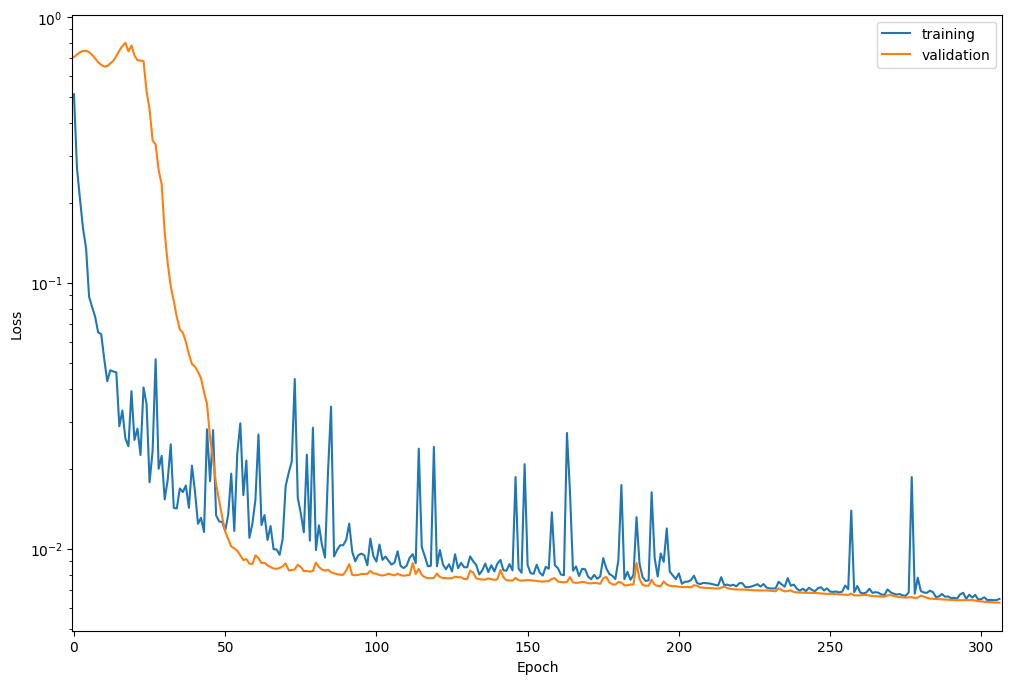

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xlim(-0.5, len(history.history["loss"]))
#plt.savefig(f"{plots_directory}Loss_CNN_PCA.png", dpi=300)
plt.show()

In [20]:
#Sanity check
print(np.mean(X_train), np.std(X_train_pca))   #mean~0, st.dev~1
print(np.mean(X_test),  np.std(X_test_pca))    #should be close to train

-1.7900246029006566 1.905736e-06
-1.7981098459738851 2.9009796e-06


In [21]:
#Get model probabilities
probs = model.predict(X_test_pca, batch_size=64).ravel()

3/3 [==============================] - 3s 155ms/step


In [22]:
#Let's check the ranges of probabilities, why is the CNN classfiying everything as LCDM?
print("min/max/mean probs:", probs.min(), probs.max(), probs.mean())

min/max/mean probs: 1.0 1.0 1.0


In [23]:
from skyneuralnets import optimal_threshold_from_roc, apply_threshold
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

out = optimal_threshold_from_roc(y_test, probs)

t_opt   = out["t_opt"]
auc_val = out["auc"]
fpr     = out["fpr"]
tpr     = out["tpr"]
thr     = out["thresholds"]

print("AUC:", auc_val, "t*:", t_opt)

#Apply the new threshold to get predictions, Youden's index https://en.wikipedia.org/wiki/Youden%27s_J_statistic
pred = apply_threshold(probs, t_opt)

AUC: 0.5 t*: inf


In [24]:
#Accuracy
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

#Confusion matrix
cm = confusion_matrix(y_test, pred, labels=[0, 1])
print("Confusion matrix:\n", cm)

Accuracy: 0.4740740740740741
Confusion matrix:
 [[64  0]
 [71  0]]


In [25]:
#-----------------------------------------------------------------------------------------------------------
#Performance: correct & incorrect  predictions
#-----------------------------------------------------------------------------------------------------------
#True positive: LCDM=0, Feature=1
true_LCDM = []
true_MoG = []
false_LCDM = []
false_MoG = []

for prob, true in zip(pred, y_test):
    if prob==0 and true==0:
        true_LCDM.append(1)
    if prob==1 and true==1:
        true_MoG.append(1)
    if prob==0 and true==1:
        false_LCDM.append(1)
    if prob==1 and true==0:
        false_MoG.append(1)
lenghts=[len(true_LCDM),len(true_MoG),len(false_LCDM),len(false_MoG)]

print('     ','LCDM','FT')
print('True ',len(true_LCDM)/sum(lenghts),len(true_MoG)/sum(lenghts))
print('False',len(false_LCDM)/sum(lenghts),len(false_MoG)/sum(lenghts))
print('--------------')
print("Correct prediction: ",(len(true_LCDM)+len(true_MoG))/sum(lenghts))
print("Wrong prediction  : ",(len(false_LCDM)+len(false_MoG))/sum(lenghts))

      LCDM FT
True  0.4740740740740741 0.0
False 0.5259259259259259 0.0
--------------
Correct prediction:  0.4740740740740741
Wrong prediction  :  0.5259259259259259


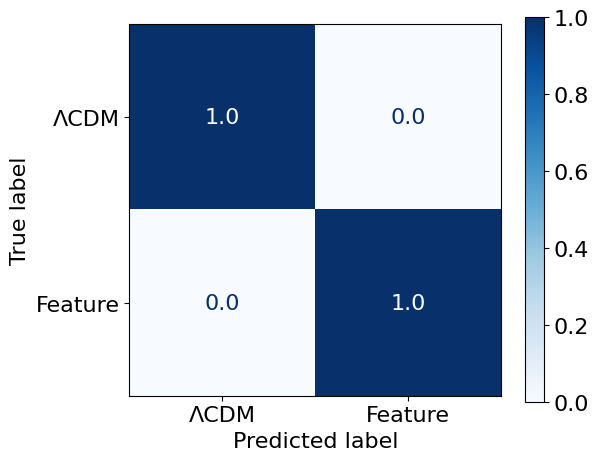

In [ ]:
#Plot confusion matrix
fsize = 16
from skyneuralnets import confusion_matrix_plot
fig, ax = confusion_matrix_plot(
    y_true=y_test,
    y_pred=pred,
    labels=("ΛCDM", "Feature"),
    cmap="Blues",
    savepath=f"{plots_directory}confusion_matrix_CNN_T_PCA.pdf"
)

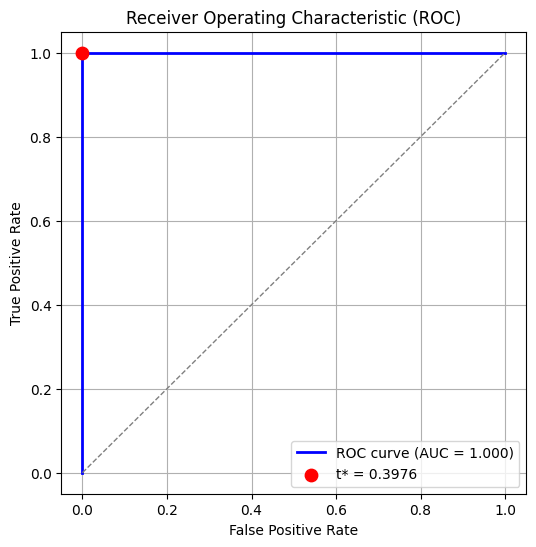

In [ ]:
#Plot the ROC curve with Youden index (https://en.wikipedia.org/wiki/Youden%27s_J_statistic#/media/File:ROC_Curve_T1D_Validation,_top5_r2filtered.svg)
from sklearn.metrics import auc
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

t_star_idx = np.argmax(tpr - fpr)
t_star = thr[t_star_idx]

#Mark t* point
plt.scatter(fpr[t_star_idx], tpr[t_star_idx], color="red", s=80, zorder=5,
            label=f"t* = {t_star:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f"{plots_directory}ROC_CNN_PCA.png", dpi=300)
plt.show()